# 🧪LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)?

The difference is whether the response variable Y gets a say in how the components are built. PCR only looks at X when it's constructing components, it just wants to capture as much variance in the predictors as it can, and it does this completely blind to Y. PLS still builds new combined variables out of the predictors, but it factors in Y while doing it, so the directions it picks are ones that explain the predictors well and are correlated with the response. PCR is unsupervised and PLS is supervised, and that changes what each one ends up prioritizing.

b. Why might PCR fail to find directions that are useful for predicting the response `Y`? 

PCR is making a pretty big assumption because it bets that the directions where the predictors vary the most are also the directions that matter for predicting Y. That's not something that's guaranteed to be true, it's just an assumption that often happens to work out reasonably well. If the actual signal that predicts Y is sitting in some direction where the predictors don't vary much, PCR is never going to prioritize that direction since it's not even looking at Y when deciding what's important. So you may end up with a model that explains X really well but completely misses the thing that actually predicts the response.

c. In PLS, how is the first direction `Z₁` computed? 

First you standardize all the predictors so they're on the same scale. Then, for each predictor, Xⱼ, you run a linear regression of Y on that one predictor and pull out the coefficient, that becomes the weight for that predictor. Z1 is then just the weighted sum of all the Xⱼ's using those coefficients. Since that coefficient is basically proportional to how correlated Y and Xⱼ are, predictors more strongly correlated with the response end up getting more weight in Z1.

d. What are some similarities and differences between PLS and penalized regression? 

The similarities are that both are built for situations where the predictors are highly correlated or where there are a lot of them relative to the number of observations, which is exactly where ordinary least squares becomes unstable. Both accept a little bias in exchange for a big cut in variance and both need the predictors standardized so no variable dominates just because of its units, and both have a single tuning knob which is the number of components for PLS, λ for ridge and lasso that you pick with cross validation. ISLR also points out that PCR and ridge are closely related, with ridge acting like a smooth version of PCR that shrinks low variance directions instead of dropping them outright. The main differences are that PLS builds entirely new variables that are linear combinations of all the original predictors, whereas ridge and lasso just shrink the coefficients on the original predictors directly without creating anything new. Lasso also has this extra property where it can push coefficients all the way to zero, which gives you actual variable selection. PLS can't do that since every single component it creates is a mix of all p of the original predictors, so nothing ever really gets dropped. Ridge and lasso never construct new directions at all, they penalizing the coefficients on the variables you already have.

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

📘 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# same synthetic 2d dataset the tutorial uses
rng = np.random.RandomState(0)
n_samples = 500
cov = [[3, 3], [3, 4]]  # makes the two features correlated
X = rng.multivariate_normal(mean=[0, 0], cov=cov, size=n_samples)

# build y off the SECOND pca direction on purpose (the low variance one)
# thats the trick here, the signal for y is hiding in the direction X barely varies in
pca = PCA(n_components=2).fit(X)
y = X.dot(pca.components_[1]) + rng.normal(size=n_samples) / 2  # add a little noise

# train/report split so we score on data the model never saw
X_train, X_report, y_train, y_report = train_test_split(
    X, y, test_size=0.5, random_state=0
)

# fit pls with just 1 component like the tutorial
pls1 = PLSRegression(n_components=1)
pls1.fit(X_train, y_train)

print("Training shape:", X_train.shape)
print("Reporting shape:", X_report.shape)
print(f"PLS (1 component) reporting R2: {pls1.score(X_report, y_report):.3f}")

Training shape: (250, 2)
Reporting shape: (250, 2)
PLS (1 component) reporting R2: 0.293


### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

1) To recreate the tutorial's PLS setup end to end and generate the correlated 2D dataset, define y so its signal lives in the low variance direction, split into training and reporting sets, and fit a 1 component PLS model.

2) The split keeps our evaluation more honest, since scoring on the training set only measures memorization. In the dataset the predictors are correlated and the useful direction has low variance, which is the exact situation PLS is designed for and the one that trips up unsupervised methods like PCR.

3) The reporting R2 shows how much of the held out y a single PLS component explains. Because PLS chooses its direction using y, that one component lands on the low variance signal, so the R2 is usually meaningfully above zero where a 1 component PCR would sit near zero.

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

PLS (2 components) reporting R2:  0.684
PLS (2 components) reporting MSE: 0.229


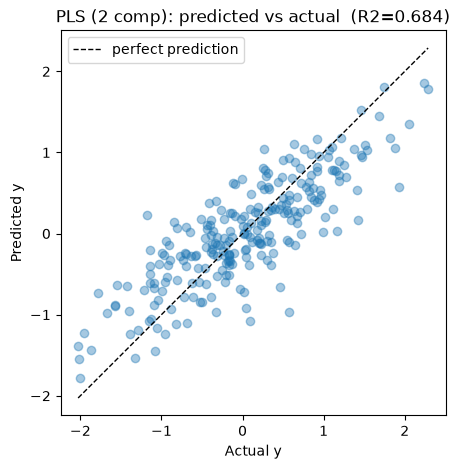

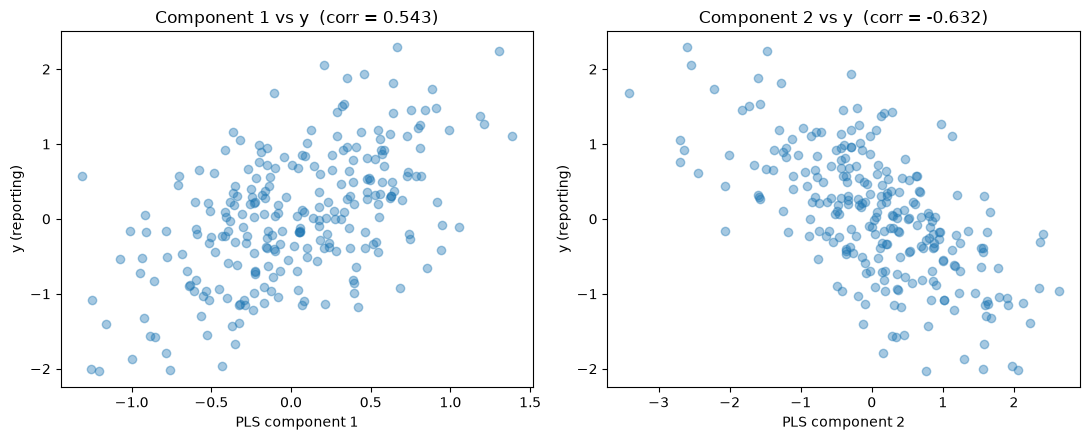

In [5]:
# refit with 2 components this time
pls2 = PLSRegression(n_components=2)
pls2.fit(X_train, y_train)

# predict on the reporting set
y_pred = pls2.predict(X_report).ravel()

# r2 and mse
r2 = r2_score(y_report, y_pred)
mse = mean_squared_error(y_report, y_pred)
print(f"PLS (2 components) reporting R2:  {r2:.3f}")
print(f"PLS (2 components) reporting MSE: {mse:.3f}")

# predicted vs actual plot, dashed line is where perfect preds would land
plt.figure(figsize=(5, 5))
plt.scatter(y_report, y_pred, alpha=0.4)
lims = [min(y_report.min(), y_pred.min()), max(y_report.max(), y_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
plt.gca().set(
    aspect="equal",
    xlabel="Actual y",
    ylabel="Predicted y",
    title=f"PLS (2 comp): predicted vs actual  (R2={r2:.3f})",
)
plt.legend()
plt.show()

# now look at each component against y 7 transform() projects X onto the pls components
T_report = pls2.transform(X_report)  # gives us both components

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, ax in enumerate(axes):
    comp = T_report[:, i]
    corr = np.corrcoef(comp, y_report)[0, 1]  # correlation for the title
    ax.scatter(comp, y_report, alpha=0.4)
    ax.set(
        xlabel=f"PLS component {i + 1}",
        ylabel="y (reporting)",
        title=f"Component {i + 1} vs y  (corr = {corr:.3f})",
    )
plt.tight_layout()
plt.show()
# component 1 should correlate way more with y than component 2

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

1) Each component is a blend of the original predictors, with weights chosen so the component tracks y. They're directions that describe X but also relate to the outcome. Here the first component captures the low variance direction that drives y, which is why it correlates much more strongly with the response than the second one.

2) Not really. The data is 2D and almost all the signal is in the first component, so the second one mostly picks up noise and leftover variance and R2 and MSE barely change. Past the point where there's real signal, extra components don't help and can hurt by fitting noise (overfitting).

3) PCA builds its directions from X alone, choosing whichever ones hold the most variance. PLS uses y as well, so it favors directions that are tied to the response rather than just the largest spread. This sample explains that the direction that matters carries almost no variance in X, so PCA and a 1 component PCR discard it, while PLS retains it because y points it there.

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).


In [3]:
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("data/lab01_data.csv")
X = data.drop(columns="permeability")
y = data["permeability"]

X_train, X_report, y_train, y_report = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Training shape:", X_train.shape)
print("Reporting shape:", X_report.shape)

Training shape: (115, 1107)
Reporting shape: (50, 1107)



### b. Create a pipeline.

Create a pipeline that includes the following: 

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.


In [18]:
pls_pipeline = Pipeline([
    ("variance", VarianceThreshold(threshold=0.05 * 0.95)), # get rid of features with low variance
    ("scale", StandardScaler()), # scale features
    ("pls", PLSRegression(scale=False)), #run pls
])

# set up 5 fold cv
cv = KFold(n_splits=5, shuffle=True, random_state=42)


### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.



In [19]:
pls_search = GridSearchCV(
    pls_pipeline, #use pls pipeline
    {"pls__n_components": range(1, 31)}, # test components from 1 to 30
    scoring="r2", # use r2 as scoring metric
    cv=cv, #user 5 fold cv we set up
)
pls_search.fit(X_train, y_train)
best_pls = pls_search.best_estimator_

print("Predictors remaining:", best_pls.named_steps["variance"].get_support().sum()) #count predictors remaining after variance thresholding
print("Best PLS components:", pls_search.best_params_["pls__n_components"]) #getbest number of components
print(f"Training CV R²: {pls_search.best_score_:.3f}")

Predictors remaining: 397
Best PLS components: 2
Training CV R²: 0.300



### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²


In [20]:
pls_predictions = best_pls.predict(X_report) #get preds
print(f"PLS reporting R²: {r2_score(y_report, pls_predictions):.3f}") #get r2 score

PLS reporting R²: 0.323



### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.



In [21]:
# Filter and scale the fingerprints, then fit Ridge regression on PCA components.
pcr_pipeline = Pipeline([
    ("variance", VarianceThreshold(threshold=0.05 * 0.95)),  # remove low-variance features
    ("scale", StandardScaler()), #scale
    ("pca", PCA(svd_solver="full")), # build pca components
    ("ridge", Ridge()), #use ridge regression to fit the pca components
])

# try different component counts and penalty strengths using same cv as before
pcr_search = GridSearchCV(
    pcr_pipeline,
    {
        "pca__n_components": [1, 2, 3, 5, 10, 15, 20, 30, 50, 80], #test different numbers of PCA components
        "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000], #test different ridge penalty strengths
    },
    scoring="r2",  #score by r2
    cv=cv,
)

# fit it to find best settings
pcr_search.fit(X_train, y_train)

# use model to predict on reporting set
pcr_predictions = pcr_search.predict(X_report)

print("Best PCR settings:", pcr_search.best_params_)
print(f"Training CV R²: {pcr_search.best_score_:.3f}")

# compare both models
results = pd.DataFrame({
    "Model": ["PLS", "PCR + Ridge"],
    "Reporting R²": [
        r2_score(y_report, pls_predictions),
        r2_score(y_report, pcr_predictions),
    ],
    "Reporting RMSE": [
        mean_squared_error(y_report, pls_predictions) ** 0.5,
        mean_squared_error(y_report, pcr_predictions) ** 0.5,
    ],
})
results.round(3) #show and round

Best PCR settings: {'pca__n_components': 50, 'ridge__alpha': 100}
Training CV R²: 0.333


,Model,Reporting R²,Reporting RMSE
0,PLS,0.323,13.166
1,PCR + Ridge,0.547,10.766



### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

PCR with Ridge did best. Its reporting R² was 0.547 vs. 0.323 for PLS, and its RMSE was lower too, 10.766 vs. 13.166. This was only one split, so it doesn't mean PCR will always do better.

I wouldn't replace the lab assay. Even PCR left about 45% of the variation unexplained (based on the R^2), and we only tested on 50 compounds. I'd want to test on more compounds and check how much error is acceptable first.

The model would save time and money, but wrong predictions could make us reject good compounds or keep bad ones. I'd use it to choose which compounds to test first, then confirm with the lab assay.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE